In [1]:
import os, struct, re, collections

RAW_DIR = r"D:\Pipeline RUL Data\data\raw"
FILES   = ["B.wfs", "C.wfs", "D.wfs", "E.wfs"]

HEADER_DUMP_BYTES = 512                 # raw hex of file start
ASCII_SCAN_BYTES  = 65536               # search for readable metadata here
WALK_SCAN_BYTES   = 50 * 1024 * 1024    # walk records over first 50 MB
SHOW_FIRST_N      = 35                  # explicitly list this many records
MIN_STR_LEN       = 4
MAX_REC_LEN       = 1 << 24             # sanity ceiling (16 MB) for a record

def hexdump(data, base=0, maxlen=HEADER_DUMP_BYTES):
    data = data[:maxlen]
    for i in range(0, len(data), 16):
        chunk = data[i:i+16]
        hexpart = " ".join(f"{b:02x}" for b in chunk).ljust(16*3)
        asciipart = "".join(chr(b) if 32 <= b < 127 else "." for b in chunk)
        print(f"  {base+i:08x}  {hexpart} |{asciipart}|")

def find_strings(data, minlen=MIN_STR_LEN):
    out = []
    for m in re.finditer(rb"[\x20-\x7e]{%d,}" % minlen, data):
        out.append((m.start(), m.group().decode("latin-1")))
    return out

def walk_records(f, start_off, scan_bytes):
    """Assume [u16 len][u8 id][payload of len-1 bytes]. advance = 2 + len."""
    f.seek(start_off)
    buf = f.read(scan_bytes)
    n = len(buf)
    off = 0
    recs_shown = 0
    id_count   = collections.Counter()
    id_lensum  = collections.Counter()
    id_lenmin  = {}
    id_lenmax  = {}
    id_sample  = {}   # first payload preview per id
    total = 0
    desync_at = None
    while off + 3 <= n:
        rlen = struct.unpack_from("<H", buf, off)[0]
        if rlen < 1 or rlen > MAX_REC_LEN:
            desync_at = start_off + off
            break
        rid = buf[off + 2]
        body_start = off + 3
        body_end   = off + 2 + rlen          # payload = rlen-1 bytes after id
        if body_end > n:
            break                            # ran past our 50 MB window (fine)
        if recs_shown < SHOW_FIRST_N:
            preview = buf[body_start:body_start+24]
            ph = " ".join(f"{b:02x}" for b in preview)
            print(f"    rec#{recs_shown:<3} @0x{start_off+off:08x}  len={rlen:<7} id={rid:<3} payload[0:24]= {ph}")
            recs_shown += 1
        id_count[rid]  += 1
        id_lensum[rid] += rlen
        id_lenmin[rid]  = min(id_lenmin.get(rid, rlen), rlen)
        id_lenmax[rid]  = max(id_lenmax.get(rid, rlen), rlen)
        if rid not in id_sample:
            id_sample[rid] = buf[body_start:body_start+32]
        total += 1
        off = off + 2 + rlen
    return dict(id_count=id_count, id_lensum=id_lensum, id_lenmin=id_lenmin,
                id_lenmax=id_lenmax, id_sample=id_sample, total=total,
                scanned=off, desync_at=desync_at)

for name in FILES:
    path = os.path.join(RAW_DIR, name)
    print("=" * 90)
    print("FILE:", path)
    if not os.path.exists(path):
        print("  !! not found"); continue
    size = os.path.getsize(path)
    print(f"  size = {size:,} bytes  ({size/1024**3:.2f} GB)")

    with open(path, "rb") as f:
        head = f.read(max(HEADER_DUMP_BYTES, ASCII_SCAN_BYTES))

        print("\n  --- raw hex (first %d bytes) ---" % HEADER_DUMP_BYTES)
        hexdump(head, 0)

        print("\n  --- readable strings in first %d bytes ---" % ASCII_SCAN_BYTES)
        strs = find_strings(head[:ASCII_SCAN_BYTES])
        if not strs:
            print("    (none)")
        for so, s in strs[:60]:
            print(f"    @0x{so:05x}  {s!r}")

        print("\n  --- record walk (first %d records, [u16 len][u8 id] framing) ---" % SHOW_FIRST_N)
        r = walk_records(f, 0, WALK_SCAN_BYTES)

        print("\n  --- record-id histogram over first %.0f MB ---" % (WALK_SCAN_BYTES/1024**2))
        print(f"    total records walked: {r['total']:,}   bytes consumed: {r['scanned']:,}")
        if r["desync_at"] is not None:
            print(f"    !! framing desynced at offset 0x{r['desync_at']:08x} "
                  f"-> length field assumption may be wrong; inspect hex above")
        print(f"    {'id':>4} {'count':>10} {'len_min':>9} {'len_max':>9} {'bytes_total':>14}  payload[0:32]")
        for rid, cnt in r["id_count"].most_common():
            smp = " ".join(f"{b:02x}" for b in r["id_sample"].get(rid, b"")[:32])
            print(f"    {rid:>4} {cnt:>10,} {r['id_lenmin'][rid]:>9} "
                  f"{r['id_lenmax'][rid]:>9} {r['id_lensum'][rid]:>14,}  {smp}")
print("=" * 90)
print("done")

FILE: D:\Pipeline RUL Data\data\raw\B.wfs
  size = 110,220,120,402 bytes  (102.65 GB)

  --- raw hex (first 512 bytes) ---
  00000000  38 00 29 00 a8 02 45 78 70 72 65 73 73 2d 38 20  |8.)...Express-8 |
  00000010  28 72 29 20 4c 6f 63 61 74 69 6f 6e 20 56 65 72  |(r) Location Ver|
  00000020  73 69 6f 6e 20 0a 0d 56 65 72 73 69 6f 6e 20 56  |sion ..Version V|
  00000030  35 2e 39 32 0a 0d 0a 0d 1a 00 0c 00 ae 6a 01 08  |5.92.........j..|
  00000040  01 02 03 04 05 06 07 08 1a 00 ae 2a 6e 00 02 01  |...........*n...|
  00000050  a0 46 66 00 00 00 e8 03 00 00 01 00 00 fc ff ff  |.Ff.............|
  00000060  0a 00 3c 00 1a 00 ae 2a 6e 00 02 02 a0 46 66 00  |..<....*n....Ff.|
  00000070  00 00 e8 03 00 00 01 00 00 fc ff ff 0a 00 3c 00  |..............<.|
  00000080  1a 00 ae 2a 6e 00 02 03 a0 46 66 00 00 00 e8 03  |...*n....Ff.....|
  00000090  00 00 01 00 00 fc ff ff 0a 00 3c 00 1a 00 ae 2a  |..........<....*|
  000000a0  6e 00 02 04 a0 46 66 00 00 00 e8 03 00 00 01 00  |n....Ff........

In [2]:
import os, struct
import numpy as np

RAW_DIR = r"D:\Pipeline RUL Data\data\raw"
FILES   = ["B.wfs", "C.wfs", "D.wfs", "E.wfs"]

CHUNK_BYTES   = 16 * 1024 * 1024      # streaming read size
SCAN_LIMIT    = 300 * 1024 * 1024     # how far to deep-decode per file
SHOW_FIRST_WF = 12                    # detailed dump of first N waveform records
WF_ID         = 0xAE                  # message wrapper
WF_SUBID      = 0x01                  # waveform sub-type
WF_HEADER     = 27                    # intra-payload header (to be verified below)
MAX_REC_LEN   = 1 << 24

def decode_wf_payload(p):
    """Return (channel, counter, samples_int16, raw_header) or None."""
    if len(p) < WF_HEADER + 2 or p[0] != WF_SUBID:
        return None
    channel = p[7]                                  # 01..08
    counter = struct.unpack_from("<Q", p, 15)[0]    # 8-byte LE counter
    data    = p[WF_HEADER:]
    if len(data) % 2:                               # keep even
        data = data[:-1]
    samples = np.frombuffer(data, dtype="<i2")
    return channel, counter, samples, p[:WF_HEADER]

def walk_stream(path, scan_limit):
    size = os.path.getsize(path)
    # per-channel accumulators
    ch_recs   = {c: 0 for c in range(1, 9)}
    ch_n      = {c: 0 for c in range(1, 9)}
    ch_min    = {c:  np.inf for c in range(1, 9)}
    ch_max    = {c: -np.inf for c in range(1, 9)}
    ch_sum    = {c: 0.0 for c in range(1, 9)}
    ch_sumsq  = {c: 0.0 for c in range(1, 9)}
    samp_lens = {}   # histogram of samples-per-record
    seq_preview = []
    shown = 0

    buf = b""
    processed = 0
    with open(path, "rb") as f:
        while processed < scan_limit:
            chunk = f.read(CHUNK_BYTES)
            if not chunk:
                break
            buf += chunk
            off = 0
            n = len(buf)
            while off + 3 <= n:
                rlen = struct.unpack_from("<H", buf, off)[0]
                if rlen < 1 or rlen > MAX_REC_LEN:
                    off += 1            # resync byte-wise (shouldn't happen)
                    continue
                end = off + 2 + rlen
                if end > n:
                    break               # incomplete record -> wait for next chunk
                rid = buf[off + 2]
                if rid == WF_ID:
                    payload = buf[off + 3: end]
                    dec = decode_wf_payload(payload)
                    if dec is not None:
                        ch, counter, samp, hdr = dec
                        if 1 <= ch <= 8:
                            s = samp.astype(np.float64)
                            ch_recs[ch]  += 1
                            ch_n[ch]     += samp.size
                            ch_min[ch]    = min(ch_min[ch], float(samp.min()) if samp.size else ch_min[ch])
                            ch_max[ch]    = max(ch_max[ch], float(samp.max()) if samp.size else ch_max[ch])
                            ch_sum[ch]   += float(s.sum())
                            ch_sumsq[ch] += float((s*s).sum())
                            samp_lens[samp.size] = samp_lens.get(samp.size, 0) + 1
                            if shown < SHOW_FIRST_WF:
                                seq_preview.append(
                                    (ch, counter, samp.size,
                                     " ".join(f"{b:02x}" for b in hdr),
                                     samp[:16].tolist()))
                                shown += 1
                off = end
            buf = buf[off:]
            processed += len(chunk)
    return dict(size=size, ch_recs=ch_recs, ch_n=ch_n, ch_min=ch_min, ch_max=ch_max,
                ch_sum=ch_sum, ch_sumsq=ch_sumsq, samp_lens=samp_lens,
                seq_preview=seq_preview, processed=processed)

for name in FILES:
    path = os.path.join(RAW_DIR, name)
    print("=" * 92)
    print("FILE:", path)
    if not os.path.exists(path):
        print("  !! not found"); continue
    r = walk_stream(path, SCAN_LIMIT)
    size = r["size"]
    print(f"  size = {size:,} bytes ({size/1024**3:.2f} GB)   deep-scanned {r['processed']/1024**2:.0f} MB")

    print("\n  --- samples-per-record histogram ---")
    for s, c in sorted(r["samp_lens"].items()):
        print(f"    {s:>6} samples/record : {c:,} records")

    print("\n  --- first waveform records (channel / counter / header / first 16 int16) ---")
    for ch, counter, ns, hdr, vals in r["seq_preview"]:
        print(f"    ch={ch}  counter={counter:<12}  ns={ns:<5}  hdr=[{hdr}]")
        print(f"        {vals}")

    print("\n  --- per-channel stats over scanned region ---")
    print(f"    {'ch':>3} {'records':>10} {'samples':>14} {'min':>8} {'max':>8} {'mean':>10} {'rms':>10}")
    SR = 1_000_000.0
    for c in range(1, 9):
        nrec = r["ch_recs"][c]; nsamp = r["ch_n"][c]
        if nsamp:
            mean = r["ch_sum"][c]/nsamp
            rms  = (r["ch_sumsq"][c]/nsamp) ** 0.5
            mn, mx = r["ch_min"][c], r["ch_max"][c]
            print(f"    {c:>3} {nrec:>10,} {nsamp:>14,} {mn:>8.0f} {mx:>8.0f} {mean:>10.2f} {rms:>10.2f}")
        else:
            print(f"    {c:>3} {0:>10} {0:>14}  (no records)")

    # whole-file estimate (assume waveform records dominate at 8222 bytes on disk)
    REC_DISK = 8222
    samp_per_rec = max(r["samp_lens"], key=r["samp_lens"].get) if r["samp_lens"] else 4096
    est_recs = (size - 729) / REC_DISK
    est_per_ch = est_recs / 8.0
    est_samp_ch = est_per_ch * samp_per_rec
    est_dur_s = est_samp_ch / SR
    print("\n  --- whole-file estimate (from size) ---")
    print(f"    est total waveform records : {est_recs:,.0f}")
    print(f"    est records per channel    : {est_per_ch:,.0f}")
    print(f"    est samples per channel    : {est_samp_ch:,.0f}")
    print(f"    est duration per channel   : {est_dur_s:,.1f} s  ({est_dur_s/60:.1f} min)")
print("=" * 92)
print("done")

FILE: D:\Pipeline RUL Data\data\raw\B.wfs
  size = 110,220,120,402 bytes (102.65 GB)   deep-scanned 304 MB

  --- samples-per-record histogram ---
      4096 samples/record : 38,769 records

  --- first waveform records (channel / counter / header / first 16 int16) ---
    ch=1  counter=969130        ns=4096   hdr=[01 64 00 aa aa aa aa 01 00 00 00 00 00 00 00 aa c9 0e 00 00 00 00 00 00 c8 0e 00]
        [-1, -2, 0, -1, 1, -2, -2, -1, 0, 0, -1, -2, 0, -1, -1, -1]
    ch=2  counter=969173        ns=4096   hdr=[01 64 00 aa aa aa aa 02 00 00 00 00 00 00 00 d5 c9 0e 00 00 00 00 00 00 c8 0e 00]
        [-2, -2, -3, -4, -3, -4, -3, -3, -4, -4, -2, -3, -4, -4, -4, -3]
    ch=3  counter=969217        ns=4096   hdr=[01 64 00 aa aa aa aa 03 00 00 00 00 00 00 00 01 ca 0e 00 00 00 00 00 00 c8 0e 00]
        [-3, -1, -2, -5, -2, -4, -4, -2, -1, 1, -4, -1, -2, -3, -2, -5]
    ch=4  counter=969261        ns=4096   hdr=[01 64 00 aa aa aa aa 04 00 00 00 00 00 00 00 2d ca 0e 00 00 00 00 00 00 c8 0e 00]
 

In [3]:
import os, struct, time
import numpy as np

RAW_DIR  = r"D:\Pipeline RUL Data\data\raw"
OUT_DIR  = r"D:\Pipeline RUL Data\data\features"
FILES    = ["B.wfs"]            # start with B; add C,D,E once timing looks good
FS       = 1_000_000.0         # 1 MHz
NS       = 4096                # samples per record (confirmed)
WF_ID    = 0xAE
WF_SUBID = 0x01
WF_HDR   = 27                  # intra-payload header length (confirmed)
CHUNK    = 32 * 1024 * 1024
MAX_REC  = 1 << 24

SCAN_CAP = 2 * 1024 * 1024 * 1024   # 2 GB trial. set to None for full file.
KEEP_TOP_EVENTS = 4000              # keep raw 8-ch windows for the N loudest records/ch
os.makedirs(OUT_DIR, exist_ok=True)

def decode(payload):
    if len(payload) < WF_HDR + 2 or payload[0] != WF_SUBID:
        return None
    ch  = payload[7]
    cnt = struct.unpack_from("<Q", payload, 15)[0]
    data = payload[WF_HDR:WF_HDR + NS*2]
    if len(data) < NS*2:
        return None
    s = np.frombuffer(data, dtype="<i2")
    return ch, cnt, s

def extract(path, scan_cap):
    size = os.path.getsize(path)
    base = os.path.splitext(os.path.basename(path))[0]
    # streaming feature accumulators: one growing list of rows per channel
    rows = {c: [] for c in range(1, 9)}     # (counter, rms, peak, absmax_idx_value)
    # min-heap-ish: keep loudest raw windows per channel
    import heapq
    heaps = {c: [] for c in range(1, 9)}    # (peak, counter, np.int16[4096])

    buf = b""
    processed = 0
    nrec = 0
    t0 = time.time()
    cnt0 = {c: None for c in range(1, 9)}

    with open(path, "rb") as f:
        while True:
            if scan_cap is not None and processed >= scan_cap:
                break
            chunk = f.read(CHUNK)
            if not chunk:
                break
            buf += chunk
            off, n = 0, len(buf)
            while off + 3 <= n:
                rlen = struct.unpack_from("<H", buf, off)[0]
                if rlen < 1 or rlen > MAX_REC:
                    off += 1; continue
                end = off + 2 + rlen
                if end > n:
                    break
                if buf[off+2] == WF_ID:
                    dec = decode(buf[off+3:end])
                    if dec is not None:
                        ch, cnt, s = dec
                        if 1 <= ch <= 8:
                            sf = s.astype(np.float32)
                            rms  = float(np.sqrt(np.mean(sf*sf)))
                            ai   = int(np.argmax(np.abs(s)))
                            peak = int(abs(s[ai]))
                            rows[ch].append((cnt, rms, peak))
                            h = heaps[ch]
                            if len(h) < KEEP_TOP_EVENTS:
                                heapq.heappush(h, (peak, cnt, s.copy()))
                            elif peak > h[0][0]:
                                heapq.heapreplace(h, (peak, cnt, s.copy()))
                            nrec += 1
                off = end
            buf = buf[off:]
            processed += len(chunk)
            if nrec and (nrec % 2_000_000 < 8):
                el = time.time()-t0
                gbps = processed/1024**3/el if el else 0
                print(f"  ...{processed/1024**3:6.2f} GB  recs={nrec:,}  "
                      f"{el:5.1f}s  {gbps:.2f} GB/s")

    # save per-channel feature arrays
    for c in range(1, 9):
        if rows[c]:
            arr = np.array(rows[c], dtype=np.float64)   # cols: counter, rms, peak
            t_s = (arr[:,0] - arr[0,0]) / FS            # time from first counter
            out = np.column_stack([arr[:,0], t_s, arr[:,1], arr[:,2]])
            np.save(os.path.join(OUT_DIR, f"{base}_ch{c}_feat.npy"), out)
    # save loudest raw windows (for TDOA)
    for c in range(1, 9):
        if heaps[c]:
            heaps[c].sort(key=lambda x: x[1])           # by counter (time order)
            counters = np.array([h[1] for h in heaps[c]], dtype=np.uint64)
            waves    = np.stack([h[2] for h in heaps[c]]).astype(np.int16)
            np.savez(os.path.join(OUT_DIR, f"{base}_ch{c}_topwaves.npz"),
                     counters=counters, waves=waves)

    el = time.time()-t0
    print(f"  DONE {base}: {nrec:,} records, {processed/1024**3:.2f} GB in {el:.1f}s")
    return nrec

for name in FILES:
    path = os.path.join(RAW_DIR, name)
    print("="*70); print("EXTRACT:", path)
    if not os.path.exists(path):
        print("  !! not found"); continue
    extract(path, SCAN_CAP)
print("="*70); print("done. features in:", OUT_DIR)

EXTRACT: D:\Pipeline RUL Data\data\raw\B.wfs
  DONE B: 261,187 records, 2.00 GB in 19.3s
done. features in: D:\Pipeline RUL Data\data\features


In [4]:
import os, numpy as np
OUT = r"D:\Pipeline RUL Data\data\features"
base = "B"
print("feature files:")
for c in range(1, 9):
    p = os.path.join(OUT, f"{base}_ch{c}_feat.npy")
    if not os.path.exists(p):
        print(f"  ch{c}: MISSING"); continue
    a = np.load(p)   # cols: counter, t_s, rms, peak
    print(f"  ch{c}: shape={a.shape}  t=[{a[:,1].min():.2f},{a[:,1].max():.2f}]s  "
          f"rms=[{a[:,2].min():.1f},{a[:,2].max():.1f}]  peak_max={a[:,3].max():.0f}")
print("\ntopwave files:")
for c in range(1, 9):
    p = os.path.join(OUT, f"{base}_ch{c}_topwaves.npz")
    if not os.path.exists(p):
        print(f"  ch{c}: MISSING"); continue
    z = np.load(p)
    w = z["waves"]
    print(f"  ch{c}: waves={w.shape}  counters={z['counters'].shape}  "
          f"global_peak={np.abs(w).max()}")

feature files:
  ch1: shape=(32649, 4)  t=[0.00,66.86]s  rms=[1.1,1.4]  peak_max=8
  ch2: shape=(32649, 4)  t=[0.00,66.86]s  rms=[2.7,3.1]  peak_max=8
  ch3: shape=(32649, 4)  t=[0.00,66.86]s  rms=[2.3,2.6]  peak_max=8
  ch4: shape=(32648, 4)  t=[0.00,66.86]s  rms=[2.2,2.5]  peak_max=8
  ch5: shape=(32648, 4)  t=[0.00,66.86]s  rms=[3.0,22.5]  peak_max=181
  ch6: shape=(32648, 4)  t=[0.00,66.86]s  rms=[2.6,23.4]  peak_max=204
  ch7: shape=(32648, 4)  t=[0.00,66.86]s  rms=[2.1,127.4]  peak_max=1314
  ch8: shape=(32648, 4)  t=[0.00,66.86]s  rms=[2.2,154.2]  peak_max=2887

topwave files:
  ch1: waves=(4000, 4096)  counters=(4000,)  global_peak=8
  ch2: waves=(4000, 4096)  counters=(4000,)  global_peak=8
  ch3: waves=(4000, 4096)  counters=(4000,)  global_peak=8
  ch4: waves=(4000, 4096)  counters=(4000,)  global_peak=8
  ch5: waves=(4000, 4096)  counters=(4000,)  global_peak=181
  ch6: waves=(4000, 4096)  counters=(4000,)  global_peak=204
  ch7: waves=(4000, 4096)  counters=(4000,)  global

In [5]:
import os, struct, time
import numpy as np

RAW_DIR  = r"D:\Pipeline RUL Data\data\raw"
OUT_DIR  = r"D:\Pipeline RUL Data\data\features"
FILES    = ["B.wfs", "C.wfs", "D.wfs", "E.wfs"]
FS       = 1_000_000.0
NS       = 4096
WF_ID    = 0xAE
WF_SUBID = 0x01
WF_HDR   = 27
CHUNK    = 32 * 1024 * 1024
MAX_REC  = 1 << 24

SCAN_CAP        = None          # full files
LIVE_CHANNELS   = (5, 6, 7, 8)  # trigger only on live sensors (confirm mapping!)
ALL_CHANNELS    = tuple(range(1, 9))
TRIG_PEAK       = 60            # int16 counts; any live ch peak above -> capture frame
MAX_EVENTS      = 20000         # cap aligned events kept per file (memory guard)
EVENT_COOLDOWN  = 5             # min frames between captures (avoid dupes on long bursts)
os.makedirs(OUT_DIR, exist_ok=True)

def decode(payload):
    if len(payload) < WF_HDR + 2 or payload[0] != WF_SUBID:
        return None
    ch  = payload[7]
    cnt = struct.unpack_from("<Q", payload, 15)[0]
    data = payload[WF_HDR:WF_HDR + NS*2]
    if len(data) < NS*2:
        return None
    return ch, cnt, np.frombuffer(data, dtype="<i2")

def extract(path, scan_cap):
    size = os.path.getsize(path)
    base = os.path.splitext(os.path.basename(path))[0]
    rows = {c: [] for c in ALL_CHANNELS}        # (counter, rms, peak) per record

    # aligned-frame assembly: collect one record per channel, flush on ch wrap
    frame = {}                                   # ch -> (counter, samples)
    last_ch = 0
    ev_counters, ev_waves = [], []               # aligned events: (8,4096)
    frames_since_event = EVENT_COOLDOWN
    n_events = 0

    def flush_frame():
        nonlocal frames_since_event, n_events
        frames_since_event += 1
        live_peak = max((int(np.abs(frame[c][1]).max())
                         for c in LIVE_CHANNELS if c in frame), default=0)
        if (live_peak >= TRIG_PEAK and frames_since_event >= EVENT_COOLDOWN
                and n_events < MAX_EVENTS
                and all(c in frame for c in ALL_CHANNELS)):
            stack = np.stack([frame[c][1] for c in ALL_CHANNELS]).astype(np.int16)
            ev_waves.append(stack)
            ev_counters.append(frame[ALL_CHANNELS[0]][0])
            frames_since_event = 0
            n_events += 1

    buf = b""; processed = 0; nrec = 0; t0 = time.time()
    with open(path, "rb") as f:
        while True:
            if scan_cap is not None and processed >= scan_cap:
                break
            chunk = f.read(CHUNK)
            if not chunk:
                break
            buf += chunk
            off, n = 0, len(buf)
            while off + 3 <= n:
                rlen = struct.unpack_from("<H", buf, off)[0]
                if rlen < 1 or rlen > MAX_REC:
                    off += 1; continue
                end = off + 2 + rlen
                if end > n:
                    break
                if buf[off+2] == WF_ID:
                    dec = decode(buf[off+3:end])
                    if dec is not None:
                        ch, cnt, s = dec
                        if 1 <= ch <= 8:
                            sf = s.astype(np.float32)
                            rows[ch].append((cnt, float(np.sqrt(np.mean(sf*sf))),
                                             int(np.abs(s).max())))
                            # frame logic: wrap when channel index resets/decreases
                            if ch <= last_ch and frame:
                                flush_frame(); frame = {}
                            frame[ch] = (cnt, s.copy())
                            last_ch = ch
                            nrec += 1
                off = end
            buf = buf[off:]
            processed += len(chunk)
            if nrec % 4_000_000 < 8:
                el = time.time()-t0
                print(f"  ...{processed/1024**3:6.2f}/{size/1024**3:.0f} GB  "
                      f"recs={nrec:,}  events={n_events:,}  {el/60:4.1f} min")
    if frame: flush_frame()

    for c in ALL_CHANNELS:
        if rows[c]:
            arr = np.array(rows[c], dtype=np.float64)
            t_s = (arr[:,0] - arr[0,0]) / FS
            np.save(os.path.join(OUT_DIR, f"{base}_ch{c}_feat.npy"),
                    np.column_stack([arr[:,0], t_s, arr[:,1], arr[:,2]]))
    if ev_waves:
        np.savez_compressed(os.path.join(OUT_DIR, f"{base}_events.npz"),
                            counters=np.array(ev_counters, dtype=np.uint64),
                            waves=np.stack(ev_waves),          # (n_events, 8, 4096)
                            channels=np.array(ALL_CHANNELS))
    el = time.time()-t0
    print(f"  DONE {base}: {nrec:,} recs, {n_events:,} aligned events, {el/60:.1f} min")

for name in FILES:
    path = os.path.join(RAW_DIR, name)
    print("="*72); print("EXTRACT:", path)
    if not os.path.exists(path):
        print("  !! not found"); continue
    extract(path, SCAN_CAP)
print("="*72); print("done ->", OUT_DIR)

EXTRACT: D:\Pipeline RUL Data\data\raw\B.wfs
  DONE B: 13,405,512 recs, 20,000 aligned events, 19.6 min
EXTRACT: D:\Pipeline RUL Data\data\raw\C.wfs
  DONE C: 12,857,016 recs, 20,000 aligned events, 19.3 min
EXTRACT: D:\Pipeline RUL Data\data\raw\D.wfs
  DONE D: 13,926,656 recs, 20,000 aligned events, 20.6 min
EXTRACT: D:\Pipeline RUL Data\data\raw\E.wfs
  DONE E: 13,974,440 recs, 20,000 aligned events, 21.4 min
done -> D:\Pipeline RUL Data\data\features


In [6]:
import os, numpy as np
OUT = r"D:\Pipeline RUL Data\data\features"
FILES = ["B", "C", "D", "E"]
LIVE = [5, 6, 7, 8]

for base in FILES:
    print("="*64); print(base)
    # --- event timing: where did the 20k events land? ---
    ev = os.path.join(OUT, f"{base}_events.npz")
    if os.path.exists(ev):
        z = np.load(ev)
        cnt = z["counters"].astype(np.float64)
        t = (cnt - cnt.min()) / 1e6        # approx seconds from first event
        w = z["waves"]                     # (n, 8, 4096)
        print(f"  events: {w.shape[0]}  t_span=[{t.min():.1f},{t.max():.1f}]s "
              f"({t.max()/60:.1f} min)")
        # how far into the FILE does the last event sit? compare to feat duration
        f5 = np.load(os.path.join(OUT, f"{base}_ch5_feat.npy"))
        file_dur = f5[:,1].max()
        print(f"  file duration (ch5 feat): {file_dur:.1f}s ({file_dur/60:.1f} min)")
        print(f"  -> events cover first {100*t.max()/file_dur:4.1f}% of the run")
        # per-live-channel peak distribution within events
        for ci, ch in enumerate([1,2,3,4,5,6,7,8]):
            if ch in LIVE:
                pk = np.abs(w[:, ci, :]).max(axis=1)
                print(f"     ch{ch}: event-peak  median={np.median(pk):.0f} "
                      f"max={pk.max():.0f}")
    else:
        print("  no events file")

    # --- degradation trajectory completeness (the prognostics substrate) ---
    print("  --- RMS trajectory (live channels) ---")
    for ch in LIVE:
        a = np.load(os.path.join(OUT, f"{base}_ch{ch}_feat.npy"))
        t = a[:,1]; rms = a[:,2]
        # late-life vs early-life RMS — does it ramp toward rupture?
        early = rms[t < 0.1*t.max()].mean()
        late  = rms[t > 0.9*t.max()].mean()
        print(f"     ch{ch}: t_max={t.max()/60:.1f}min  rms early={early:.1f} "
              f"late={late:.1f}  ramp×{late/max(early,1e-9):.1f}")

B
  events: 20000  t_span=[0.0,717.8]s (12.0 min)
  file duration (ch5 feat): 3431.8s (57.2 min)
  -> events cover first 20.9% of the run
     ch5: event-peak  median=19 max=5422
     ch6: event-peak  median=19 max=6333
     ch7: event-peak  median=64 max=6508
     ch8: event-peak  median=51 max=6689
  --- RMS trajectory (live channels) ---
     ch5: t_max=57.2min  rms early=3.3 late=8.3  ramp×2.5
     ch6: t_max=57.2min  rms early=2.7 late=7.4  ramp×2.7
     ch7: t_max=57.2min  rms early=2.3 late=21.1  ramp×9.0
     ch8: t_max=57.2min  rms early=2.8 late=17.5  ramp×6.3
C
  events: 20000  t_span=[0.0,836.9]s (13.9 min)
  file duration (ch5 feat): 3291.4s (54.9 min)
  -> events cover first 25.4% of the run
     ch5: event-peak  median=22 max=6712
     ch6: event-peak  median=19 max=6236
     ch7: event-peak  median=62 max=4980
     ch8: event-peak  median=60 max=5588
  --- RMS trajectory (live channels) ---
     ch5: t_max=54.9min  rms early=3.6 late=6.7  ramp×1.9
     ch6: t_max=54.9mi

In [7]:
import os, struct, time, random
import numpy as np

RAW_DIR  = r"D:\Pipeline RUL Data\data\raw"
OUT_DIR  = r"D:\Pipeline RUL Data\data\features"
FILES    = ["B.wfs", "C.wfs", "D.wfs", "E.wfs"]
FS, NS, WF_ID, WF_SUBID, WF_HDR = 1_000_000.0, 4096, 0xAE, 0x01, 27
CHUNK, MAX_REC = 32*1024*1024, 1 << 24

LIVE_CHANNELS = (5, 6, 7, 8)
ALL_CHANNELS  = tuple(range(1, 9))
TRIG_PEAK     = 200          # raised: catch real bursts, not low-level chatter
RESERVOIR_K   = 15000        # events kept, uniformly across the WHOLE run
random.seed(0)
os.makedirs(OUT_DIR, exist_ok=True)

def decode(p):
    if len(p) < WF_HDR + 2 or p[0] != WF_SUBID: return None
    return p[7], struct.unpack_from("<Q", p, 15)[0], np.frombuffer(p[WF_HDR:WF_HDR+NS*2], "<i2")

def extract(path):
    base = os.path.splitext(os.path.basename(path))[0]
    frame, last_ch = {}, 0
    res_w, res_c = [], []          # reservoir of (8,4096) windows + counters
    seen = 0
    def consider():
        nonlocal seen
        if not all(c in frame for c in ALL_CHANNELS): return
        live_peak = max(int(np.abs(frame[c][1]).max()) for c in LIVE_CHANNELS)
        if live_peak < TRIG_PEAK: return
        seen += 1
        stack = np.stack([frame[c][1] for c in ALL_CHANNELS]).astype(np.int16)
        c0 = frame[ALL_CHANNELS[0]][0]
        if len(res_w) < RESERVOIR_K:
            res_w.append(stack); res_c.append(c0)
        else:
            j = random.randint(0, seen-1)
            if j < RESERVOIR_K:
                res_w[j] = stack; res_c[j] = c0
    buf=b""; nrec=0; t0=time.time(); size=os.path.getsize(path)
    with open(path,"rb") as f:
        while True:
            chunk=f.read(CHUNK)
            if not chunk: break
            buf+=chunk; off,n=0,len(buf)
            while off+3<=n:
                rlen=struct.unpack_from("<H",buf,off)[0]
                if rlen<1 or rlen>MAX_REC: off+=1; continue
                end=off+2+rlen
                if end>n: break
                if buf[off+2]==WF_ID:
                    d=decode(buf[off+3:end])
                    if d is not None:
                        ch,cnt,s=d
                        if 1<=ch<=8:
                            if ch<=last_ch and frame: consider(); frame={}
                            frame[ch]=(cnt,s.copy()); last_ch=ch; nrec+=1
                off=end
            buf=buf[off:]
            if nrec % 4_000_000 < 8:
                print(f"  ...{nrec:,} recs  kept={len(res_w)} seen={seen:,}  {(time.time()-t0)/60:.1f}min")
    if frame: consider()
    order=np.argsort(np.array(res_c,dtype=np.uint64))
    np.savez_compressed(os.path.join(OUT_DIR,f"{base}_events_full.npz"),
        counters=np.array(res_c,dtype=np.uint64)[order],
        waves=np.stack(res_w)[order], channels=np.array(ALL_CHANNELS))
    print(f"  DONE {base}: kept {len(res_w)} events from {seen:,} triggers, {(time.time()-t0)/60:.1f}min")

for name in FILES:
    p=os.path.join(RAW_DIR,name); print("="*64,"\nEXTRACT:",p)
    if os.path.exists(p): extract(p)
print("done ->",OUT_DIR)

EXTRACT: D:\Pipeline RUL Data\data\raw\B.wfs
  DONE B: kept 2375 events from 2,375 triggers, 12.9min
EXTRACT: D:\Pipeline RUL Data\data\raw\C.wfs
  DONE C: kept 1734 events from 1,734 triggers, 12.7min
EXTRACT: D:\Pipeline RUL Data\data\raw\D.wfs
  DONE D: kept 2809 events from 2,809 triggers, 13.1min
EXTRACT: D:\Pipeline RUL Data\data\raw\E.wfs
  DONE E: kept 4811 events from 4,811 triggers, 14.6min
done -> D:\Pipeline RUL Data\data\features


In [8]:
import os, numpy as np
OUT = r"D:\Pipeline RUL Data\data\features"
for base in ["B","C","D","E"]:
    z = np.load(os.path.join(OUT, f"{base}_events_full.npz"))
    cnt = z["counters"].astype(np.float64); w = z["waves"]   # (n,8,4096)
    t = (cnt - cnt.min())/1e6
    fdur = np.load(os.path.join(OUT, f"{base}_ch5_feat.npy"))[:,1].max()
    # event density in last 10% of run (rupture approach) vs first 10%
    early = np.mean(t < 0.1*fdur); late = np.mean(t > 0.9*fdur)
    print(f"{base}: n={w.shape[0]}  t_span=[{t.min():.0f},{t.max():.0f}]s "
          f"covers {100*t.max()/fdur:.0f}% of run | frac early10%={early:.2f} late10%={late:.2f}")
    pk = np.abs(w).max(axis=2)  # (n,8) peak per channel per event
    print("    per-ch median event-peak:",
          {f"ch{c}": int(np.median(pk[:,c-1])) for c in range(1,9)})

B: n=2375  t_span=[0,3411]s covers 99% of run | frac early10%=0.03 late10%=0.70
    per-ch median event-peak: {'ch1': 6, 'ch2': 7, 'ch3': 7, 'ch4': 6, 'ch5': 508, 'ch6': 441, 'ch7': 211, 'ch8': 607}
C: n=1734  t_span=[0,3246]s covers 99% of run | frac early10%=0.09 late10%=0.58
    per-ch median event-peak: {'ch1': 5, 'ch2': 7, 'ch3': 7, 'ch4': 6, 'ch5': 201, 'ch6': 232, 'ch7': 331, 'ch8': 508}
D: n=2809  t_span=[0,3553]s covers 100% of run | frac early10%=0.03 late10%=0.84
    per-ch median event-peak: {'ch1': 6, 'ch2': 8, 'ch3': 7, 'ch4': 7, 'ch5': 667, 'ch6': 4314, 'ch7': 95, 'ch8': 1030}
E: n=4811  t_span=[0,3569]s covers 100% of run | frac early10%=0.05 late10%=0.76
    per-ch median event-peak: {'ch1': 6, 'ch2': 8, 'ch3': 7, 'ch4': 7, 'ch5': 557, 'ch6': 1997, 'ch7': 106, 'ch8': 677}


saved D:\Pipeline RUL Data\data\figs\HI_trajectories.png

pipe           HI  Monotonicity  Trendability
   B      ch5_rms         0.034         0.214
   B      ch6_rms         0.042         0.198
   B      ch7_rms         0.018         0.567
   B      ch8_rms         0.010         0.373
   B    fused_rms         0.006         0.544
   B   cum_energy         1.000         0.993
   C      ch5_rms         0.054         0.411
   C      ch6_rms         0.026         0.533
   C      ch7_rms         0.026         0.560
   C      ch8_rms         0.030         0.553
   C    fused_rms         0.026         0.521
   C   cum_energy         1.000         0.990
   D      ch5_rms         0.014         0.172
   D      ch6_rms         0.030         0.219
   D      ch7_rms         0.042         0.354
   D      ch8_rms         0.018         0.267
   D    fused_rms         0.002         0.276
   D   cum_energy         1.000         0.995
   E      ch5_rms         0.006         0.161
   E      ch6_rms     

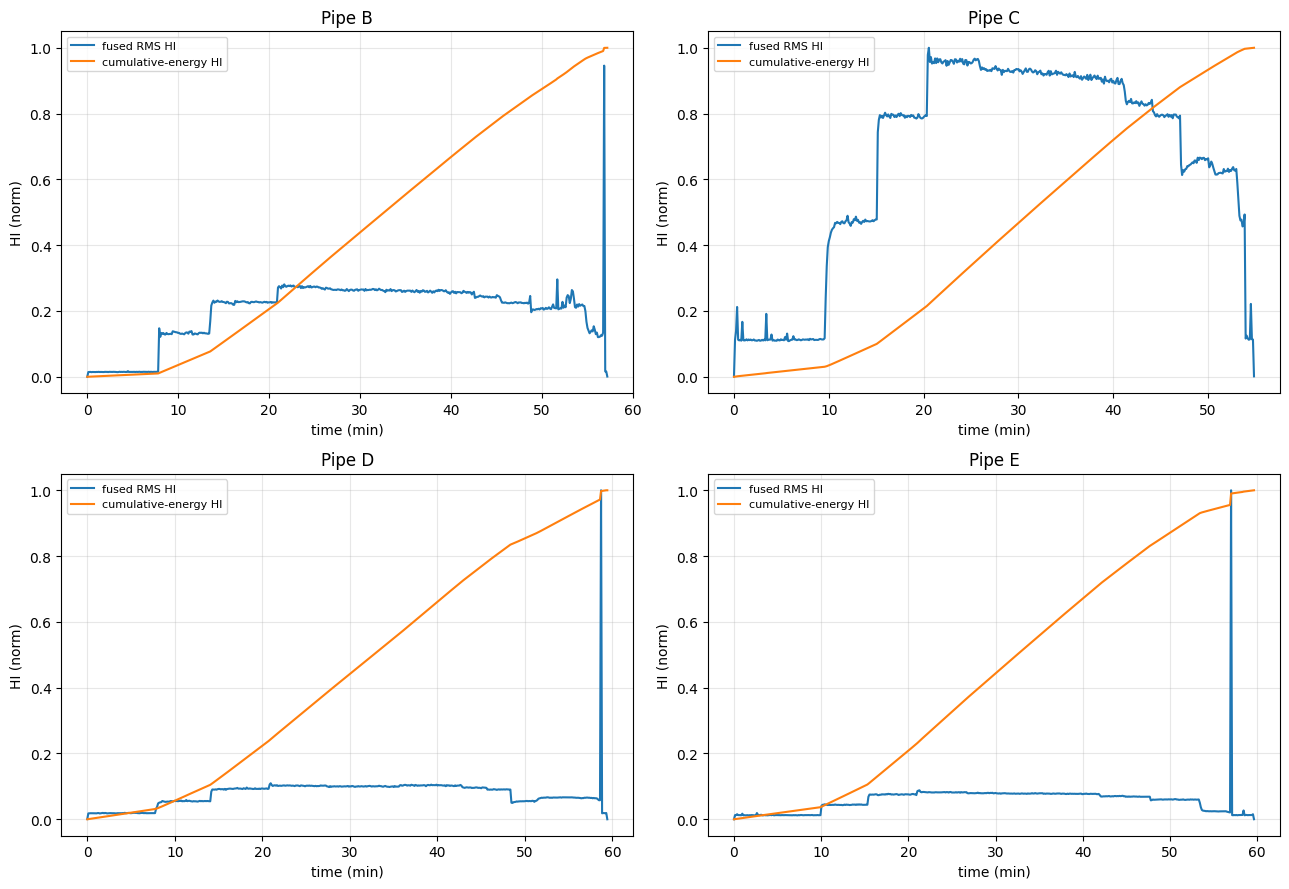

In [10]:
import os, numpy as np
import matplotlib.pyplot as plt

OUT = r"D:\Pipeline RUL Data\data\features"
FIG = r"D:\Pipeline RUL Data\data\figs"; os.makedirs(FIG, exist_ok=True)
FILES = ["B","C","D","E"]
LIVE = [5,6,7,8]

def monotonicity(x):                      # paper Eq.(4)
    d = np.sign(np.diff(x)); return abs(d.sum())/(len(x)-1)
def trendability(x):                      # paper Eq.(5): |corr(x,t)|
    t = np.arange(len(x))
    return abs(np.corrcoef(x, t)[0,1])

def smooth(x, k=51):
    if len(x) < k: return x
    ker = np.ones(k)/k
    return np.convolve(x, ker, mode="same")

def resample(t, y, n=500):                # uniform time grid for fair Mon/Tren
    tg = np.linspace(t.min(), t.max(), n)
    return tg, np.interp(tg, t, y)

results = {}
fig, axes = plt.subplots(2, 2, figsize=(13,9))
for ax, base in zip(axes.ravel(), FILES):
    feats = {c: np.load(os.path.join(OUT, f"{base}_ch{c}_feat.npy")) for c in LIVE}
    his = {}
    for c in LIVE:
        t, rms = feats[c][:,1], feats[c][:,2]
        tg, rg = resample(t, smooth(rms))
        his[f"ch{c}_rms"] = (tg, rg)
    tg = his[f"ch{LIVE[0]}_rms"][0]
    stack = np.vstack([np.interp(tg, his[f"ch{c}_rms"][0], his[f"ch{c}_rms"][1]) for c in LIVE])
    norm = (stack - stack.min(1, keepdims=True)) / (np.ptp(stack, axis=1, keepdims=True)+1e-9)
    fused = norm.mean(0)
    cum = np.cumsum(fused); cum = cum/cum.max()

    res = {}
    for name,(tt,yy) in his.items():
        res[name] = (monotonicity(yy), trendability(yy))
    res["fused_rms"]   = (monotonicity(fused), trendability(fused))
    res["cum_energy"]  = (monotonicity(cum),   trendability(cum))
    results[base] = res

    ax.plot(tg/60, fused, label="fused RMS HI", lw=1.5)
    ax.plot(tg/60, cum,   label="cumulative-energy HI", lw=1.5)
    ax.set_title(f"Pipe {base}"); ax.set_xlabel("time (min)"); ax.set_ylabel("HI (norm)")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG,"HI_trajectories.png"), dpi=130)
print("saved", os.path.join(FIG,"HI_trajectories.png"))

print(f"\n{'pipe':>4} {'HI':>12} {'Monotonicity':>13} {'Trendability':>13}")
for base in FILES:
    for name,(m,tr) in results[base].items():
        print(f"{base:>4} {name:>12} {m:>13.3f} {tr:>13.3f}")
print("\nIEEE Access (Nguyen 2024) reference: CFAR-hit HI  Mon=0.94  Tren=1.00")
print("Compare your fused_rms / cum_energy rows against that.")

In [11]:
import os, numpy as np
OUT = r"D:\Pipeline RUL Data\data\features"
FILES = ["B","C","D","E"]; LIVE=[5,6,7,8]; FS=1e6
try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import cross_val_predict
except ImportError:
    raise SystemExit("pip install scikit-learn")

def smooth(x,k=101):
    if len(x)<k: return x
    return np.convolve(x, np.ones(k)/k, mode="same")

def build(base, dt_s=2.0):
    feats = {c: np.load(os.path.join(OUT,f"{base}_ch{c}_feat.npy")) for c in LIVE}
    tmax = min(feats[c][:,1].max() for c in LIVE)
    grid = np.arange(0, tmax, dt_s)
    rms  = np.vstack([np.interp(grid, feats[c][:,1], smooth(feats[c][:,2])) for c in LIVE])
    pk   = np.vstack([np.interp(grid, feats[c][:,1], smooth(feats[c][:,3])) for c in LIVE])
    rms_sorted = -np.sort(-rms, axis=0)          # geometry-invariant (descending)
    pk_sorted  = -np.sort(-pk,  axis=0)
    erate = (rms**2).sum(0)                       # instantaneous energy rate
    cum   = np.cumsum(erate); cum/=cum[-1]        # normalized cumulative energy (clock-like; flagged)
    X = np.column_stack([rms_sorted.T, pk_sorted.T, erate, cum])
    rul = (tmax - grid)/60.0                      # RUL in minutes
    return X, rul

# assemble per-pipe
data = {b: build(b) for b in FILES}
ncol = data["B"][0].shape[1]
colnames = [f"rms{i}" for i in range(4)]+[f"pk{i}" for i in range(4)]+["erate","cumE"]

alpha = 0.10   # target 90% coverage
print(f"LOPO conformal RUL  (target coverage {1-alpha:.0%})\n")
print(f"{'test':>4} {'MAE_min':>8} {'RMSE_min':>9} {'cover':>7} {'half-width_min':>15}")
for test in FILES:
    Xtr = np.vstack([data[b][0] for b in FILES if b!=test])
    ytr = np.concatenate([data[b][1] for b in FILES if b!=test])
    Xte, yte = data[test]
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=0)
    # calibration residuals via out-of-fold preds on the 3 training pipes
    oof = cross_val_predict(m, Xtr, ytr, cv=3, n_jobs=-1)
    q = np.quantile(np.abs(ytr-oof), 1-alpha)     # conformal half-width
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    err = pred - yte
    cover = np.mean(np.abs(err) <= q)
    print(f"{test:>4} {np.mean(np.abs(err)):>8.2f} {np.sqrt(np.mean(err**2)):>9.2f} "
          f"{cover:>7.2%} {q:>15.2f}")

# feature importance from a full-data fit (diagnostic)
mm = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=0)
Xall = np.vstack([data[b][0] for b in FILES]); yall=np.concatenate([data[b][1] for b in FILES])
mm.fit(Xall, yall)
print("\nfeature importance:")
for n,v in sorted(zip(colnames, mm.feature_importances_), key=lambda z:-z[1]):
    print(f"  {n:>6}: {v:.3f}")

LOPO conformal RUL  (target coverage 90%)

test  MAE_min  RMSE_min   cover  half-width_min
   B     1.74      2.05 100.00%            7.10
   C     2.15      2.59  97.81%            5.08
   D     3.55      4.97  86.76%            6.39
   E     2.75      3.61  85.52%            5.01

feature importance:
    cumE: 0.812
    rms1: 0.094
    rms2: 0.061
     pk2: 0.026
    rms3: 0.002
     pk1: 0.001
   erate: 0.001
    rms0: 0.001
     pk3: 0.001
     pk0: 0.001


In [12]:
import os, numpy as np
OUT = r"D:\Pipeline RUL Data\data\features"
FILES=["B","C","D","E"]; LIVE=[5,6,7,8]
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict

def smooth(x,k=101):
    return x if len(x)<k else np.convolve(x,np.ones(k)/k,mode="same")

def build(base, dt_s=2.0):
    feats={c:np.load(os.path.join(OUT,f"{base}_ch{c}_feat.npy")) for c in LIVE}
    tmax=min(feats[c][:,1].max() for c in LIVE)
    grid=np.arange(0,tmax,dt_s)
    rms=np.vstack([np.interp(grid,feats[c][:,1],smooth(feats[c][:,2])) for c in LIVE])
    pk =np.vstack([np.interp(grid,feats[c][:,1],smooth(feats[c][:,3])) for c in LIVE])
    rms_s=-np.sort(-rms,axis=0); pk_s=-np.sort(-pk,axis=0)
    erate=(rms**2).sum(0)
    cum=np.cumsum(erate)                          # RAW cumulative — NOT normalized by final (no leakage)
    logcum=np.log1p(cum)
    # causal rolling slope of top-channel rms (online-computable degradation rate)
    top=rms_s[0]; slope=np.gradient(top)
    roll=np.array([top[max(0,i-30):i+1].mean() for i in range(len(top))])
    X=np.column_stack([rms_s.T, pk_s.T, erate, logcum, slope, roll])
    rul=(tmax-grid)/60.0
    return X,rul

cols=[f"rms{i}" for i in range(4)]+[f"pk{i}" for i in range(4)]+["erate","logcum","slope","roll"]
data={b:build(b) for b in FILES}
alpha=0.10
print(f"HONEST LOPO conformal RUL (no cumE-normalization leakage), target {1-alpha:.0%}\n")
print(f"{'test':>4} {'MAE':>6} {'RMSE':>6} {'cover':>7} {'hw_min':>7}")
maes=[]
for test in FILES:
    Xtr=np.vstack([data[b][0] for b in FILES if b!=test])
    ytr=np.concatenate([data[b][1] for b in FILES if b!=test])
    Xte,yte=data[test]
    m=RandomForestRegressor(n_estimators=300,min_samples_leaf=5,n_jobs=-1,random_state=0)
    oof=cross_val_predict(m,Xtr,ytr,cv=3,n_jobs=-1)
    q=np.quantile(np.abs(ytr-oof),1-alpha)
    m.fit(Xtr,ytr); pred=m.predict(Xte); err=pred-yte
    maes.append(np.mean(np.abs(err)))
    print(f"{test:>4} {np.mean(np.abs(err)):>6.2f} {np.sqrt(np.mean(err**2)):>6.2f} "
          f"{np.mean(np.abs(err)<=q):>7.2%} {q:>7.2f}")
print(f"\nmean LOPO MAE: {np.mean(maes):.2f} min")
mm=RandomForestRegressor(n_estimators=300,min_samples_leaf=5,n_jobs=-1,random_state=0)
Xall=np.vstack([data[b][0] for b in FILES]); yall=np.concatenate([data[b][1] for b in FILES])
mm.fit(Xall,yall)
print("\nfeature importance (honest):")
for n,v in sorted(zip(cols,mm.feature_importances_),key=lambda z:-z[1]):
    print(f"  {n:>7}: {v:.3f}")

HONEST LOPO conformal RUL (no cumE-normalization leakage), target 90%

test    MAE   RMSE   cover  hw_min
   B   1.76   1.99  99.77%    4.80
   C   2.55   2.89  77.46%    3.93
   D   3.28   3.62  69.71%    3.79
   E   2.14   2.36  97.93%    4.38

mean LOPO MAE: 2.43 min

feature importance (honest):
   logcum: 0.881
     rms1: 0.095
     roll: 0.010
      pk2: 0.009
     rms2: 0.003
      pk3: 0.001
      pk0: 0.001
    erate: 0.000
     rms3: 0.000
     rms0: 0.000
      pk1: 0.000
    slope: 0.000


In [13]:
import os, numpy as np
OUT = r"D:\Pipeline RUL Data\data\features"
FILES=["B","C","D","E"]; LIVE=[5,6,7,8]

def smooth(x,k=101):
    return x if len(x)<k else np.convolve(x,np.ones(k)/k,mode="same")

def load_grid(base, dt_s=1.0):
    feats={c:np.load(os.path.join(OUT,f"{base}_ch{c}_feat.npy")) for c in LIVE}
    tmax=min(feats[c][:,1].max() for c in LIVE)
    grid=np.arange(0,tmax,dt_s)
    rms=np.vstack([np.interp(grid,feats[c][:,1],smooth(feats[c][:,2])) for c in LIVE])
    return grid, rms, tmax   # rms: (4, T)

# --- conformal in-control calibration ---
# nonconformity score: per-time max-over-live-channel RMS (geometry-invariant).
# "in-control" = first CAL_FRAC of life. threshold = (1-alpha) quantile of in-control scores.
# alarm = first time a run of >=PERSIST consecutive points exceed threshold.
CAL_FRAC = 0.30        # first 30% of life assumed in-control (normal)
alpha    = 0.01        # target in-control false-alarm rate (1%)
PERSIST  = 10          # consecutive exceedances required (debounce single spikes)

print(f"Conformal terminal-regime alarm | in-control=first {CAL_FRAC:.0%}, "
      f"target FAR={alpha:.0%}, persist={PERSIST}\n")
print(f"{'pipe':>4} {'life_min':>8} {'thr':>7} {'alarm_min':>9} {'lead_min':>8} "
      f"{'IC_FAR':>7} {'fired':>6}")
rows=[]
for base in FILES:
    grid, rms, tmax = load_grid(base)
    score = rms.max(0)                       # (T,) geometry-invariant nonconformity
    T=len(grid); n_cal=int(CAL_FRAC*T)
    cal=score[:n_cal]
    thr=np.quantile(cal, 1-alpha)            # conformal threshold
    # empirical in-control false-alarm rate on the held *calibration* region (sanity)
    ic_far = np.mean(cal>thr)
    # detection: first PERSIST-long run above thr, searched over WHOLE trajectory
    exc=(score>thr).astype(int)
    run=0; alarm_idx=None
    for i in range(T):
        run = run+1 if exc[i] else 0
        if run>=PERSIST: alarm_idx=i-PERSIST+1; break
    if alarm_idx is None:
        print(f"{base:>4} {tmax/60:>8.1f} {thr:>7.1f} {'--':>9} {'--':>8} {ic_far:>7.2%} {'NO':>6}")
        rows.append((base,tmax,thr,None,None,ic_far)); continue
    t_alarm=grid[alarm_idx]; lead=(tmax-t_alarm)/60
    print(f"{base:>4} {tmax/60:>8.1f} {thr:>7.1f} {t_alarm/60:>9.1f} {lead:>8.1f} "
          f"{ic_far:>7.2%} {'yes':>6}")
    rows.append((base,tmax,thr,t_alarm,lead,ic_far))

print("\nReading the table:")
print(" - lead_min = minutes of warning before rupture (bigger = more actionable)")
print(" - IC_FAR should sit at/below target alpha (conformal validity check)")
print(" - if alarm fires in last <1 min, detector is useless -> need earlier score")

Conformal terminal-regime alarm | in-control=first 30%, target FAR=1%, persist=10

pipe life_min     thr alarm_min lead_min  IC_FAR  fired
   B     57.2    25.7      20.9     36.3   1.07%    yes
   C     54.9    24.7      20.4     34.5   1.01%    yes
   D     59.4    22.6      20.8     38.6   1.03%    yes
   E     59.6    27.0      21.0     38.6   1.03%    yes

Reading the table:
 - lead_min = minutes of warning before rupture (bigger = more actionable)
 - IC_FAR should sit at/below target alpha (conformal validity check)
 - if alarm fires in last <1 min, detector is useless -> need earlier score


In [14]:
import os, numpy as np
OUT=r"D:\Pipeline RUL Data\data\features"; FILES=["B","C","D","E"]; LIVE=[5,6,7,8]
def smooth(x,k=101): return x if len(x)<k else np.convolve(x,np.ones(k)/k,mode="same")
def load_grid(base,dt_s=1.0):
    f={c:np.load(os.path.join(OUT,f"{base}_ch{c}_feat.npy")) for c in LIVE}
    tmax=min(f[c][:,1].max() for c in LIVE); grid=np.arange(0,tmax,dt_s)
    rms=np.vstack([np.interp(grid,f[c][:,1],smooth(f[c][:,2])) for c in LIVE])
    return grid,rms,tmax

def alarm_time(score,grid,cal_frac,alpha,persist):
    T=len(grid); thr=np.quantile(score[:int(cal_frac*T)],1-alpha)
    exc=(score>thr).astype(int); run=0
    for i in range(T):
        run=run+1 if exc[i] else 0
        if run>=persist: return grid[i-persist+1], thr
    return None,thr

# TEST 1: does alarm follow rupture or follow the calibration edge?
print("TEST 1 — calibration sensitivity (max-RMS score), alpha=1%, persist=10")
print(f"{'pipe':>4} {'life':>6} " + " ".join(f"cal{int(c*100)}%" for c in [0.15,0.20,0.30,0.40]))
for base in FILES:
    grid,rms,tmax=load_grid(base); score=rms.max(0); out=[]
    for cf in [0.15,0.20,0.30,0.40]:
        ta,_=alarm_time(score,grid,cf,0.01,10)
        out.append(f"{ta/60:5.1f}" if ta is not None else "  -- ")
    print(f"{base:>4} {tmax/60:>6.1f} "+" ".join(out))
print(" -> if alarm-min slides DOWN as cal% shrinks, it's tracking the cal edge (ARTIFACT).")
print("    if alarm-min stays put, the regime is physically anchored (REAL).\n")

# TEST 2: sharper precursor score = causal rate-of-rise of max-RMS (turns at acceleration, not level)
print("TEST 2 — precursor score (derivative of max-RMS), cal=30%, alpha=1%, persist=10")
print(f"{'pipe':>4} {'life':>6} {'alarm':>6} {'lead':>6} {'IC_FAR':>7}")
for base in FILES:
    grid,rms,tmax=load_grid(base)
    base_s=rms.max(0)
    deriv=np.gradient(smooth(base_s,51))         # rate of rise
    deriv=np.clip(deriv,0,None)                  # only upward acceleration counts
    T=len(grid); thr=np.quantile(deriv[:int(0.3*T)],0.99)
    ic=np.mean(deriv[:int(0.3*T)]>thr)
    exc=(deriv>thr).astype(int); run=0; ta=None
    for i in range(T):
        run=run+1 if exc[i] else 0
        if run>=10: ta=grid[i-9]; break
    if ta is None: print(f"{base:>4} {tmax/60:>6.1f} {'--':>6} {'--':>6} {ic:>7.2%}")
    else: print(f"{base:>4} {tmax/60:>6.1f} {ta/60:>6.1f} {(tmax-ta)/60:>6.1f} {ic:>7.2%}")

TEST 1 — calibration sensitivity (max-RMS score), alpha=1%, persist=10
pipe   life cal15% cal20% cal30% cal40%
   B   57.2  13.5  13.5  20.9   -- 
   C   54.9   9.7  14.3  20.4  20.4
   D   59.4   9.9  14.1  20.8  20.9
   E   59.6   9.9  15.3  21.0  21.1
 -> if alarm-min slides DOWN as cal% shrinks, it's tracking the cal edge (ARTIFACT).
    if alarm-min stays put, the regime is physically anchored (REAL).

TEST 2 — precursor score (derivative of max-RMS), cal=30%, alpha=1%, persist=10
pipe   life  alarm   lead  IC_FAR
   B   57.2     --     --   1.07%
   C   54.9     --     --   1.01%
   D   59.4    8.1   51.4   1.03%
   E   59.6     --     --   1.03%
